In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import math



In [22]:
df=pd.read_csv(r"D:\code\datasets\ParisHousing.csv")
df.head()


,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityCode,cityPartRange,numPrevOwners,made,isNewBuilt,hasStormProtector,basement,attic,garage,hasStorageRoom,hasGuestRoom,price
0,75523,3,0,1,63,9373,3,8,2005,0,1,4313,9005,956,0,7,7559081.5
1,80771,39,1,1,98,39381,8,6,2015,1,0,3653,2436,128,1,2,8085989.5
2,55712,58,0,1,19,34457,6,8,2021,0,0,2937,8852,135,1,9,5574642.1
3,32316,47,0,0,6,27939,10,4,2012,0,1,659,7141,359,0,3,3232561.2
4,70429,19,1,1,90,38045,3,7,1990,1,0,8435,2429,292,1,4,7055052.0


In [23]:
df.shape

(10000, 17)

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   squareMeters       10000 non-null  int64  
 1   numberOfRooms      10000 non-null  int64  
 2   hasYard            10000 non-null  int64  
 3   hasPool            10000 non-null  int64  
 4   floors             10000 non-null  int64  
 5   cityCode           10000 non-null  int64  
 6   cityPartRange      10000 non-null  int64  
 7   numPrevOwners      10000 non-null  int64  
 8   made               10000 non-null  int64  
 9   isNewBuilt         10000 non-null  int64  
 10  hasStormProtector  10000 non-null  int64  
 11  basement           10000 non-null  int64  
 12  attic              10000 non-null  int64  
 13  garage             10000 non-null  int64  
 14  hasStorageRoom     10000 non-null  int64  
 15  hasGuestRoom       10000 non-null  int64  
 16  price              10000 non-null 

In [25]:
nulls_per_col = df.isna().sum().sort_values(ascending=False)
print("Nulls per column:\n", nulls_per_col)
print("/////////////////////////////------///////////////////////////")
has_nulls = df.isna().any().any()
print("Has any nulls?:", has_nulls)

Nulls per column:
 squareMeters         0
numberOfRooms        0
hasYard              0
hasPool              0
floors               0
cityCode             0
cityPartRange        0
numPrevOwners        0
made                 0
isNewBuilt           0
hasStormProtector    0
basement             0
attic                0
garage               0
hasStorageRoom       0
hasGuestRoom         0
price                0
dtype: int64
/////////////////////////////------///////////////////////////
Has any nulls?: False


In [ ]:
def load_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    # Ensure numeric
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def zscore_outliers(df: pd.DataFrame, cols, threshold: float = 3.0):
    out = {}
    for c in cols:
        x = df[c].astype(float)
        mu = x.mean()
        sd = x.std(ddof=0)
        if sd == 0 or np.isnan(sd):
            out[c] = df.index[x.notna() & (False)].tolist()
            continue
        z = (x - mu) / sd
        out[c] = df.index[(x.notna()) & (np.abs(z) > threshold)].tolist()
    return out


def iqr_outliers(df: pd.DataFrame, cols):
    out = {}
    for c in cols:
        x = df[c].astype(float)
        q1 = x.quantile(0.25)
        q3 = x.quantile(0.75)
        iqr = q3 - q1
        lo = q1 - 1.5 * iqr
        hi = q3 + 1.5 * iqr
        out[c] = df.index[x.notna() & ((x < lo) | (x > hi))].tolist()
    return out


def model_outliers(df: pd.DataFrame, feature_cols, random_state: int = 42, contamination: float = 0.01):
    X = df[feature_cols].copy()
    X = X.replace([np.inf, -np.inf], np.nan).dropna(axis=0)

    scaler = StandardScaler()
    Xs = scaler.fit_transform(X.values)

    # Isolation Forest
    iso = IsolationForest(
        n_estimators=300,
        random_state=random_state,
        contamination=contamination,
    )
    iso_pred = iso.fit_predict(Xs)  # -1 outlier, 1 inlier
    iso_scores = iso.decision_function(Xs)  # higher -> more normal

    # LOF
    lof = LocalOutlierFactor(n_neighbors=20, contamination=contamination)
    lof_pred = lof.fit_predict(Xs)  # -1 outlier, 1 inlier
    lof_scores = lof.negative_outlier_factor_  # more negative -> more outlier

    res = pd.DataFrame(
        {
            "index": X.index,
            "iso_label": iso_pred,
            "iso_score": iso_scores,
            "lof_label": lof_pred,
            "lof_score": lof_scores,
        }
    ).sort_values("iso_label")

    return res, X

In [ ]:
def main():
    path ="D:\code\datasets\ParisHousing.csv"
    df = load_data(path)

    feature_cols = [c for c in df.columns if c != "price"]

    print("Loaded:", df.shape)
    print("Columns:", list(df.columns))

    # 1) Univariate outliers (Z-score & IQR) on key numeric features
    key_cols = ["price", "squareMeters", "numberOfRooms", "floors", "numPrevOwners", "cityPartRange", "made", "garage"]
    key_cols = [c for c in key_cols if c in df.columns]

    print("\n--- Univariate outliers (Z-score |z| > 3) ---")
    z_out = zscore_outliers(df, key_cols, threshold=3.0)
    for c, idxs in z_out.items():
        print(f"{c}: {len(idxs)} rows")

    print("\n--- Univariate outliers (IQR rule) ---")
    iqr_out = iqr_outliers(df, key_cols)
    for c, idxs in iqr_out.items():
        print(f"{c}: {len(idxs)} rows")

    # 2) Multivariate outliers (IsolationForest + LOF) using all features except price
    print("\n--- Multivariate outliers (IsolationForest & LOF) ---")
    results, used_df = model_outliers(df, feature_cols=feature_cols, contamination=0.01)

    # Show most suspicious points
    out_iso = results[results["iso_label"] == -1].sort_values("iso_score")
    out_lof = results[results["lof_label"] == -1].sort_values("lof_score")

    print(f"IsolationForest detected {len(out_iso)} outliers (contamination=0.01)")
    if len(out_iso):
        print(out_iso.head(10)[["index", "iso_label", "iso_score", "lof_label", "lof_score"]])

    print(f"LOF detected {len(out_lof)} outliers (contamination=0.01)")
    if len(out_lof):
        print(out_lof.head(10)[["index", "iso_label", "iso_score", "lof_label", "lof_score"]])



if __name__ == "__main__":
    main()

Loaded: (10000, 17)
Columns: ['squareMeters', 'numberOfRooms', 'hasYard', 'hasPool', 'floors', 'cityCode', 'cityPartRange', 'numPrevOwners', 'made', 'isNewBuilt', 'hasStormProtector', 'basement', 'attic', 'garage', 'hasStorageRoom', 'hasGuestRoom', 'price']

--- Univariate outliers (Z-score |z| > 3) ---
price: 0 rows
squareMeters: 0 rows
numberOfRooms: 0 rows
floors: 0 rows
numPrevOwners: 0 rows
cityPartRange: 0 rows
made: 0 rows
garage: 0 rows

--- Univariate outliers (IQR rule) ---
price: 0 rows
squareMeters: 0 rows
numberOfRooms: 0 rows
floors: 0 rows
numPrevOwners: 0 rows
cityPartRange: 0 rows
made: 0 rows
garage: 0 rows

--- Multivariate outliers (IsolationForest & LOF) ---


IsolationForest detected 100 outliers (contamination=0.01)
      index  iso_label  iso_score  lof_label  lof_score
3180   3180         -1  -0.025071         -1  -1.178831
8256   8256         -1  -0.021814         -1  -1.127888
5070   5070         -1  -0.015082         -1  -1.133314
2795   2795         -1  -0.014633         -1  -1.142939
373     373         -1  -0.014607         -1  -1.114427
6439   6439         -1  -0.014385         -1  -1.109302
8490   8490         -1  -0.013930         -1  -1.114400
6443   6443         -1  -0.013837         -1  -1.173134
2103   2103         -1  -0.013748         -1  -1.147269
6249   6249         -1  -0.013646         -1  -1.162538
LOF detected 100 outliers (contamination=0.01)
      index  iso_label  iso_score  lof_label  lof_score
3180   3180         -1  -0.025071         -1  -1.178831
6443   6443         -1  -0.013837         -1  -1.173134
6249   6249         -1  -0.013646         -1  -1.162538
30       30         -1  -0.007186         -1  -1.16124

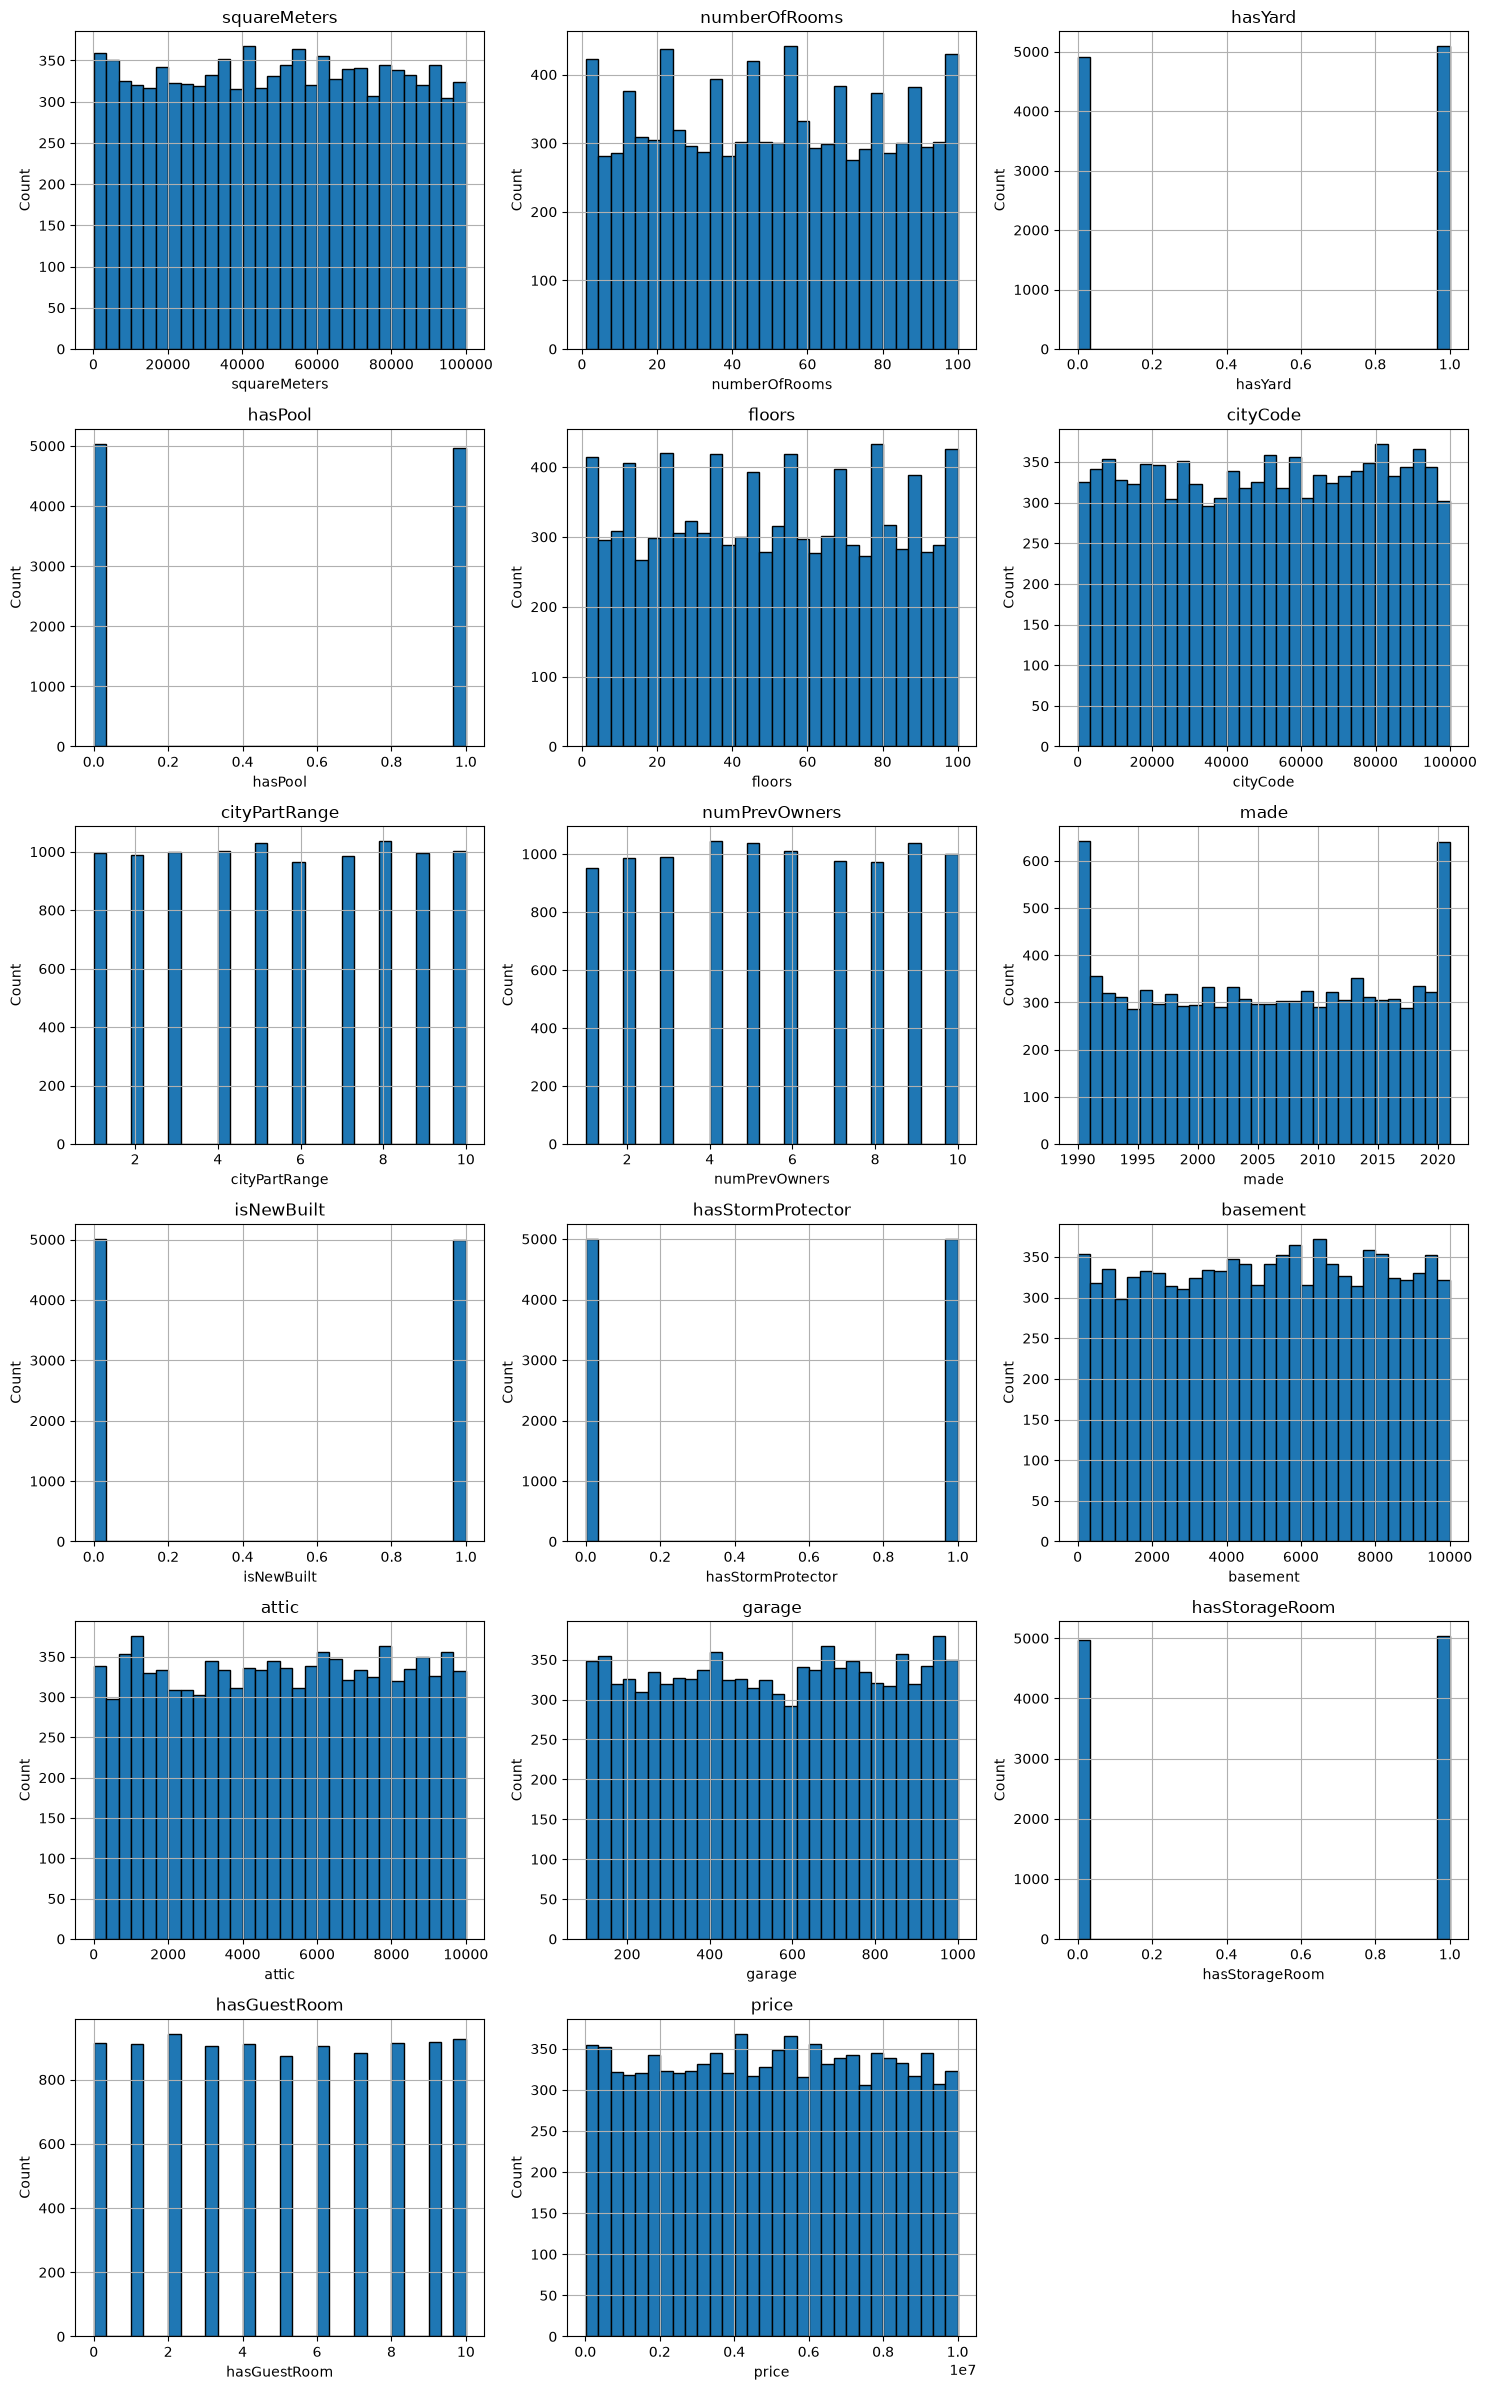

In [ ]:
numeric_cols = df.select_dtypes(include=["number"]).columns

n = len(numeric_cols)
cols = 3  # adjust grid layout
rows = (n + cols - 1) // cols

plt.figure(figsize=(5*cols, 4*rows))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    df[col].hist(bins=30, edgecolor="black")
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()


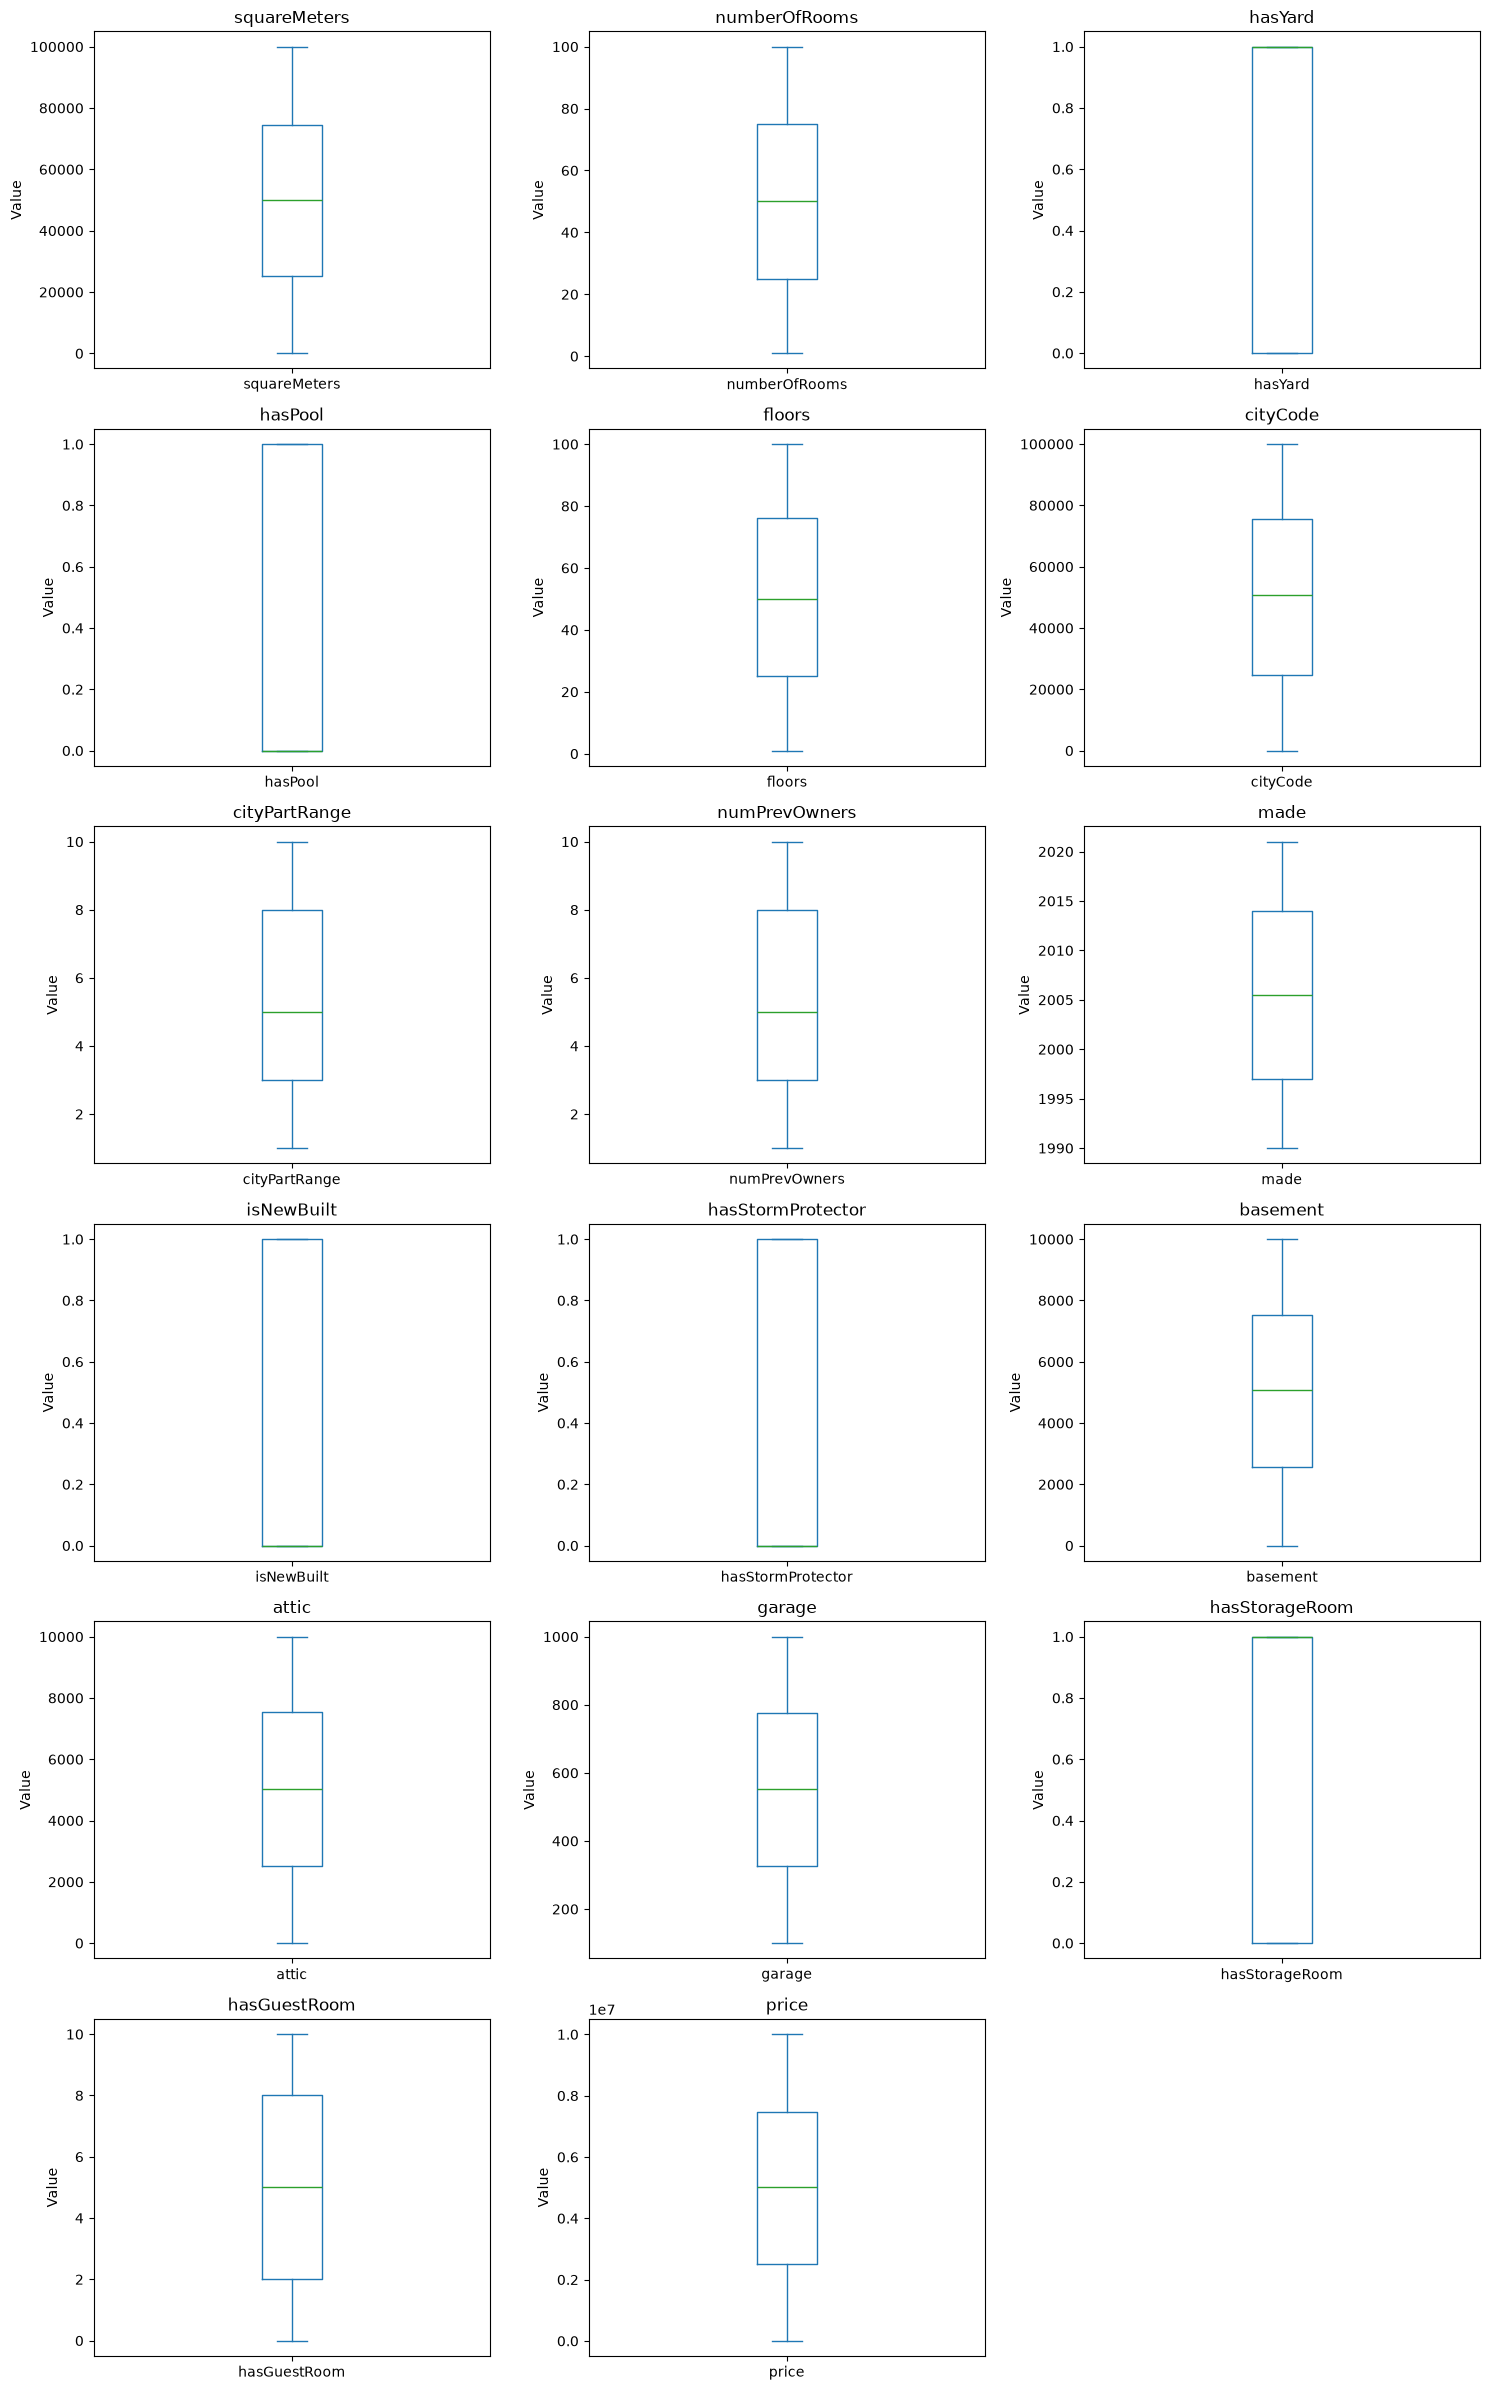

In [ ]:
numeric_cols = df.select_dtypes(include=["number"]).columns

cols = 3
rows = math.ceil(len(numeric_cols) / cols)

plt.figure(figsize=(5*cols, 4*rows))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    df[col].plot(kind="box", vert=True)
    plt.title(col)
    plt.ylabel("Value")

plt.tight_layout()
plt.show()


In [30]:
# Check how many duplicate rows exist
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)

# Delete duplicate rows (keep the first occurrence)
df_clean = df.drop_duplicates()

print("Original shape:", df.shape)
print("Clean shape:", df_clean.shape)


Duplicate rows: 0
Original shape: (10000, 17)
Clean shape: (10000, 17)


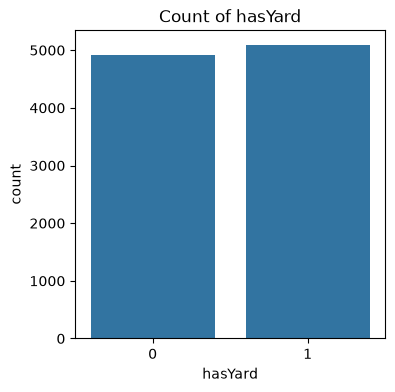

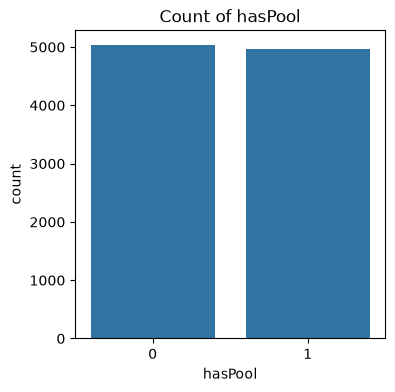

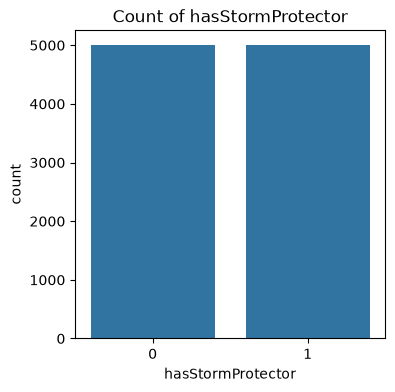

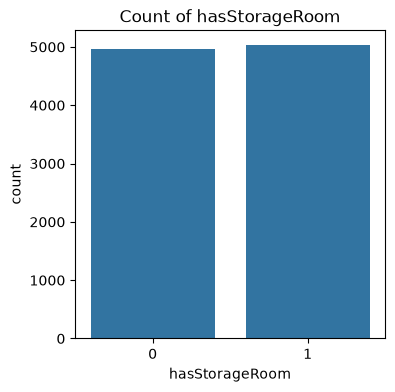

In [ ]:
yard_col = "hasYard"
poll_col = "hasPool"
storm_protector='hasStormProtector'
storage_room='hasStorageRoom'

def plot_parplots_and_counts(df, col):
    # Count plot (number of 0/1)
    plt.figure(figsize=(4,4))
    sns.countplot(x=col, data=df)
    plt.title(f"Count of {col}")
    plt.show()


plot_parplots_and_counts(df, yard_col)
plot_parplots_and_counts(df, poll_col)
plot_parplots_and_counts(df, storm_protector)
plot_parplots_and_counts(df, storage_room)


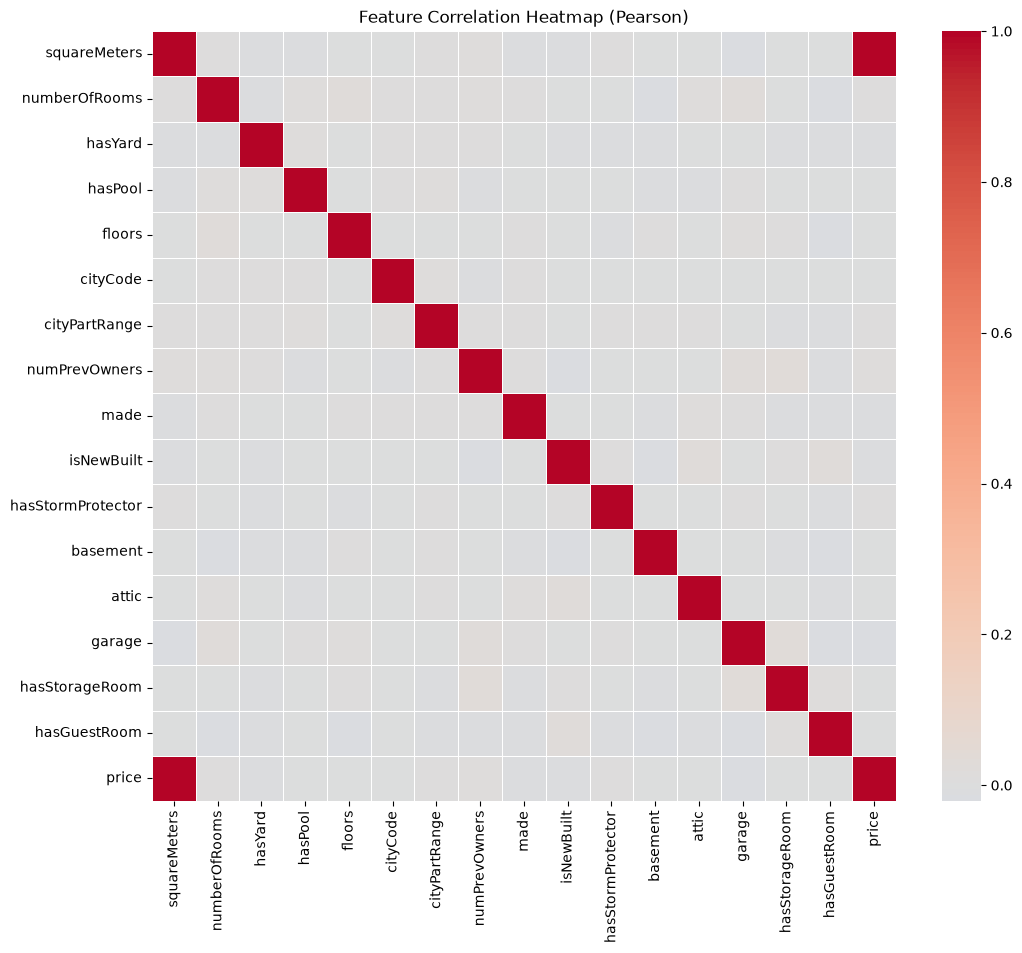

In [32]:
numeric_cols = df.select_dtypes(include=["number"]).columns
corr = df[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap (Pearson)")
plt.show()


In [ ]:
from sklearn.decomposition import PCA

# cleaned dataset (as you said, your name is df)
data = df.copy()

target_col = "price"  # change if your target column is not 'price'
if target_col not in data.columns:
    raise ValueError(f"Target column '{target_col}' not found. Columns: {list(data.columns)}")

X = data.drop(columns=[target_col])
y = data[target_col].astype(float)

cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ],
    remainder="drop"
)

# ---- split first (avoid leakage) ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---- fit preprocess on train, transform train/test ----
X_train_pre = preprocess.fit_transform(X_train)
X_test_pre = preprocess.transform(X_test)

# ---- PCA: keep 95% variance (you can change to 90/99) ----
PCA_VARIANCE = 0.95
pca = PCA(n_components=PCA_VARIANCE, random_state=42)

X_train_pca = pca.fit_transform(X_train_pre)
X_test_pca = pca.transform(X_test_pre)

print("Original preprocessed dim:", X_train_pre.shape[1])
print("Reduced PCA dim:", X_train_pca.shape[1])


Original preprocessed dim: 16
Reduced PCA dim: 16


In [ ]:


models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001, max_iter=20000),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=20000),
    "KNN": KNeighborsRegressor(n_neighbors=7),
    "RandomForest": RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1, min_samples_leaf=2),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=600, random_state=42, n_jobs=-1, min_samples_leaf=2),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "SVR_RBF": SVR(kernel="rbf", C=10, gamma="scale", epsilon=0.1),
}

results = []
best_rmse = float("inf")
best_name = None
best_model = None

for name, model in models.items():
    model.fit(X_train_pca, y_train)
    preds = model.predict(X_test_pca)

    rmse = float(np.sqrt(mean_squared_error(y_test, preds)))
    r2 = float(r2_score(y_test, preds))

    results.append((name, rmse, r2))
    print(f"{name:18s} | RMSE: {rmse:,.2f} | R2: {r2:.4f}")

    if rmse < best_rmse:
        best_rmse = rmse
        best_name = name
        best_model = model

results_df = pd.DataFrame(results, columns=["model", "rmse", "r2"]).sort_values("rmse")
display(results_df)

print(f"\nBest model: {best_name} | RMSE={best_rmse:,.2f}")


LinearRegression   | RMSE: 1,922.42 | R2: 1.0000
Ridge              | RMSE: 1,956.08 | R2: 1.0000
Lasso              | RMSE: 1,922.42 | R2: 1.0000
ElasticNet         | RMSE: 2,422.57 | R2: 1.0000
KNN                | RMSE: 1,298,414.68 | R2: 0.8075
RandomForest       | RMSE: 1,163,727.86 | R2: 0.8454
ExtraTrees         | RMSE: 1,086,316.45 | R2: 0.8653
GradientBoosting   | RMSE: 934,278.82 | R2: 0.9003
SVR_RBF            | RMSE: 2,960,813.01 | R2: -0.0009


,model,rmse,r2
0,LinearRegression,1.922423e+03,1.000000
2,Lasso,1.922423e+03,1.000000
1,Ridge,1.956080e+03,1.000000
3,ElasticNet,2.422571e+03,0.999999
7,GradientBoosting,9.342788e+05,0.900342
6,ExtraTrees,1.086316e+06,0.865268
5,RandomForest,1.163728e+06,0.845382
4,KNN,1.298415e+06,0.807521
8,SVR_RBF,2.960813e+06,-0.000874



Best model: LinearRegression | RMSE=1,922.42


Best model: LinearRegression


,y_true,y_pred
7739,9885598.3,9.889857e+06
3204,3158232.0,3.156042e+06
3238,3278517.5,3.279766e+06
7019,5923843.0,5.928378e+06
4058,268725.5,2.677193e+05
9828,5586343.0,5.586255e+06
1886,6864163.4,6.862586e+06
9414,5175060.2,5.177960e+06
6625,7719651.6,7.720338e+06
3033,4337442.9,4.338279e+06


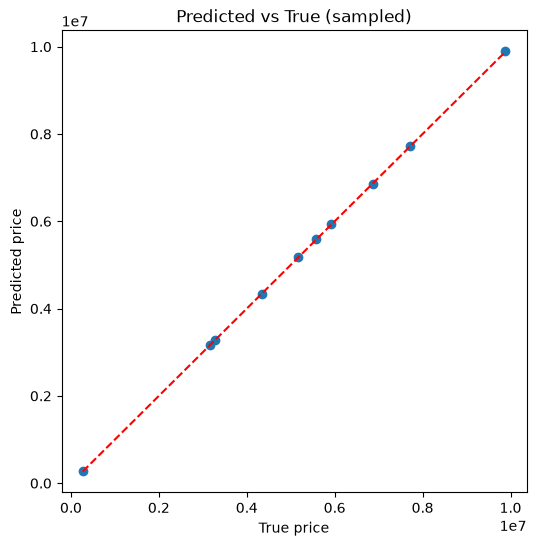

In [36]:
# ---- pick some samples from your test set ----
N = 10
idx = np.random.choice(len(X_test), size=min(N, len(X_test)), replace=False)
X_sample = X_test.iloc[idx]
y_sample = y_test.iloc[idx] if hasattr(y_test, 'iloc') else y_test[idx]

# ---- preprocess -> PCA -> predict with best_model ----
X_sample_pre = preprocess.transform(X_sample)
X_sample_pca = pca.transform(X_sample_pre)

preds = best_model.predict(X_sample_pca)

# ---- show results ----
check = pd.DataFrame({
    'y_true': y_sample,
    'y_pred': preds,
})
print('Best model:', best_name)
display(check)


plt.figure(figsize=(6,6))
plt.scatter(y_sample, preds)
plt.xlabel('True price')
plt.ylabel('Predicted price')
plt.title('Predicted vs True (sampled)')
plt.plot([y_sample.min(), y_sample.max()], [y_sample.min(), y_sample.max()], 'r--')
plt.show()
